In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, CategoricalNB

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Görselleştirme ayarları
sns.set_theme(style="whitegrid")

In [ ]:
print("--- CAR EVALUATION VERİ SETİ BAŞLIYOR ---")
car_df = pd.read_csv('car evaluation.csv', header=None)
car_df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

# 2. Kategorik Verileri Sayısallaştırma (Label Encoding)
le = LabelEncoder()
for col in car_df.columns:
    car_df[col] = le.fit_transform(car_df[col])

X_car = car_df.drop('class', axis=1)
y_car = car_df['class']


class_counts = y_car.value_counts()
rare_classes = class_counts[class_counts < 2].index

if not rare_classes.empty:
    print(f"Warning: The following classes have fewer than 2 members and will be excluded for stratification: {list(rare_classes)}")

    filtered_indices = y_car[~y_car.isin(rare_classes)].index
    X_car_filtered = X_car.loc[filtered_indices]
    y_car_filtered = y_car.loc[filtered_indices]
else:
    X_car_filtered = X_car
    y_car_filtered = y_car


# 3. Tren / Test Ayrımı (%80 - %20)
X_train_car, X_test_car, y_train_car, y_test_car = train_test_split(
    X_car_filtered, y_car_filtered, test_size=0.20, random_state=42, stratify=y_car_filtered
)

--- CAR EVALUATION VERİ SETİ BAŞLIYOR ---


In [1]:
# Modelleri tanımlayalım
knn_car = KNeighborsClassifier(n_neighbors=5)
nb_car = CategoricalNB()

# --- GÜNCELLEME: Filtrelenmiş Train verileriyle eğitiyoruz ---
knn_car.fit(X_train_car, y_train_car)
nb_car.fit(X_train_car, y_train_car)

# Tahminler
knn_pred_car = knn_car.predict(X_test_car)
nb_pred_car = nb_car.predict(X_test_car)

# --- GÜNCELLEME: 5-Fold CV yaparken de filtrelenmiş tüm veriyi veriyoruz ---
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# X_car yerine X_car_filtered, y_car yerine y_car_filtered kullandık:
knn_cv_car = cross_val_score(knn_car, X_car_filtered, y_car_filtered, cv=cv_strategy, scoring='accuracy')
nb_cv_car = cross_val_score(nb_car, X_car_filtered, y_car_filtered, cv=cv_strategy, scoring='accuracy')

print(f"KNN Car 5-Fold Ortalama Accuracy: {knn_cv_car.mean():.4f} (Std Dev: {knn_cv_car.std():.4f})")
print(f"Naive Bayes Car 5-Fold Ortalama Accuracy: {nb_cv_car.mean():.4f} (Std Dev: {nb_cv_car.std():.4f})")

NameError: name 'KNeighborsClassifier' is not defined

In [ ]:
print("\n--- SPAM VERİ SETİ BAŞLIYOR ---")
spam_df = pd.read_csv('spam.csv', encoding='latin-1')
# Gereksiz kolonlar varsa temizleyelim ve isimlendirelim
spam_df = spam_df.iloc[:, [0, 1]]
spam_df.columns = ['label', 'text']

# Hedef değişkeni sayısallaştırma (spam=1, ham=0)
spam_df['label'] = le.fit_transform(spam_df['label'])

X_spam_raw = spam_df['text']
y_spam = spam_df['label']

# 2. Tren / Test Ayrımı
X_train_msg, X_test_msg, y_train_spam, y_test_spam = train_test_split(
    X_spam_raw, y_spam, test_size=0.20, random_state=42, stratify=y_spam
)

# 3. Metinleri Kelime Frekans Matrisine Çevirme (Vektörleştirme)
vectorizer = CountVectorizer()
X_train_spam = vectorizer.fit_transform(X_train_msg)
X_test_spam = vectorizer.transform(X_test_msg)
# Tüm veri seti CV için vektörleştiriliyor
X_spam_all = vectorizer.fit_transform(X_spam_raw)


--- SPAM VERİ SETİ BAŞLIYOR ---


In [ ]:
# Modelleri tanımlayalım
knn_spam = KNeighborsClassifier(n_neighbors=5)
nb_spam = MultinomialNB() # Metin/Kelime sayımları için en ideal Naive Bayes türü

# Modelleri eğitelim
knn_spam.fit(X_train_spam, y_train_spam)
nb_spam.fit(X_train_spam, y_train_spam)

# Tahminler
knn_pred_spam = knn_spam.predict(X_test_spam)
nb_pred_spam = nb_spam.predict(X_test_spam)

# 5-Fold CV Analizi
knn_cv_spam = cross_val_score(knn_spam, X_spam_all, y_spam, cv=cv_strategy, scoring='accuracy')
nb_cv_spam = cross_val_score(nb_spam, X_spam_all, y_spam, cv=cv_strategy, scoring='accuracy')

print(f"KNN Spam 5-Fold Ortalama Accuracy: {knn_cv_spam.mean():.4f} (Std Dev: {knn_cv_spam.std():.4f})")
print(f"Naive Bayes Spam 5-Fold Ortalama Accuracy: {nb_cv_spam.mean():.4f} (Std Dev: {nb_cv_spam.std():.4f})")

KNN Spam 5-Fold Ortalama Accuracy: 0.9185 (Std Dev: 0.0042)
Naive Bayes Spam 5-Fold Ortalama Accuracy: 0.9824 (Std Dev: 0.0027)



--- GRAFİKLER ÜRETİLİYOR ---


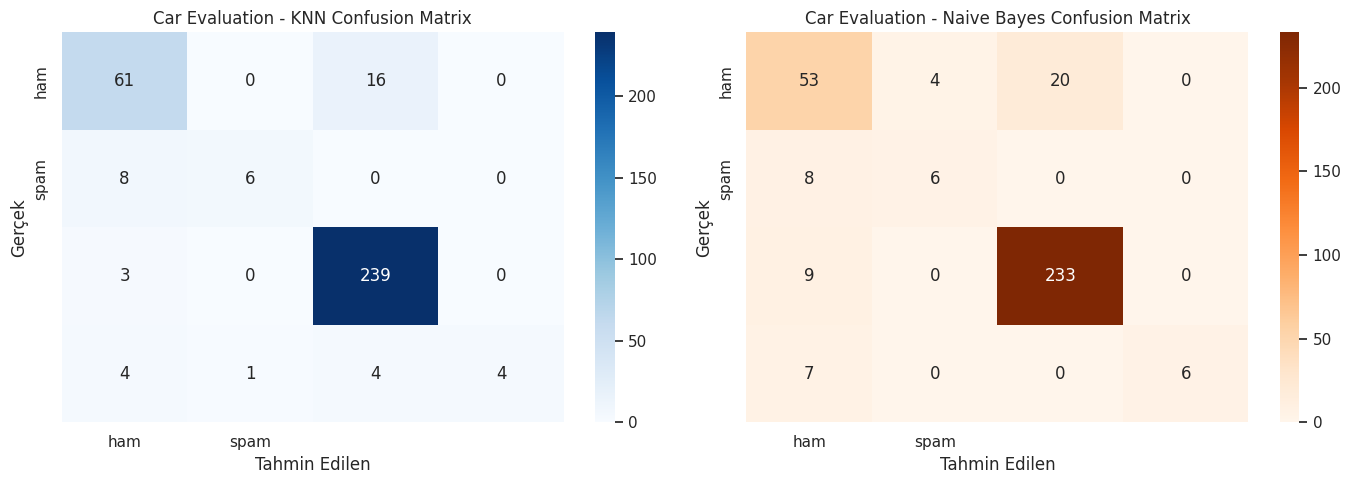

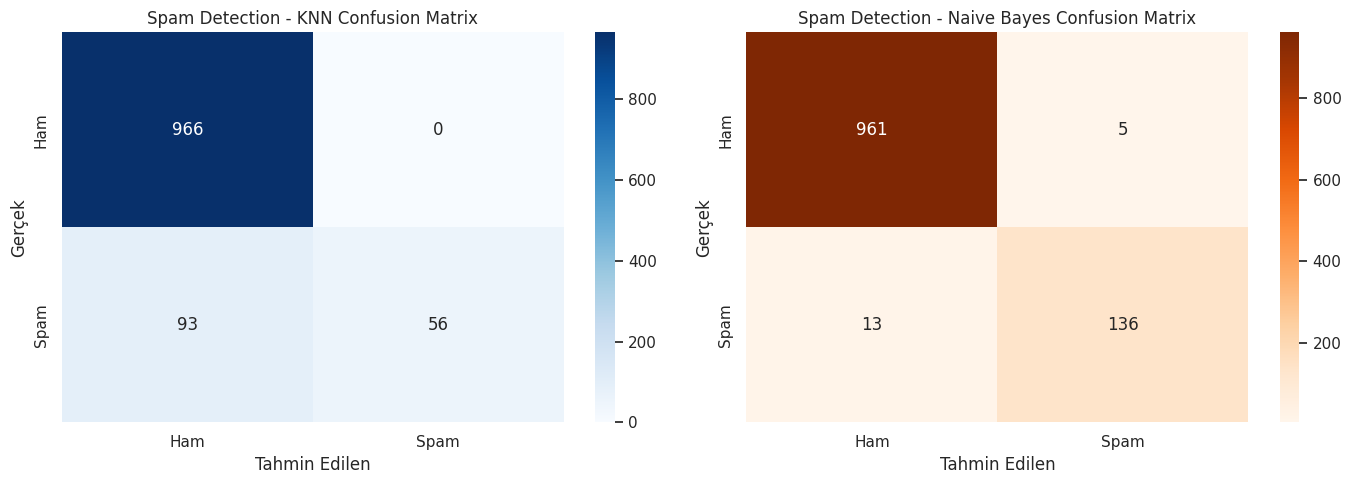


=== CAR EVALUATION DETAYLI RAPOR ===
--- KNN ---
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        77
           2       0.86      0.43      0.57        14
           3       0.92      0.99      0.95       242
           4       1.00      0.31      0.47        13

    accuracy                           0.90       346
   macro avg       0.90      0.63      0.70       346
weighted avg       0.90      0.90      0.89       346

--- NAIVE BAYES ---
              precision    recall  f1-score   support

           0       0.69      0.69      0.69        77
           2       0.60      0.43      0.50        14
           3       0.92      0.96      0.94       242
           4       1.00      0.46      0.63        13

    accuracy                           0.86       346
   macro avg       0.80      0.64      0.69       346
weighted avg       0.86      0.86      0.86       346


=== SPAM DETECTION DETAYLI RAPOR ===
--- KNN ---
          

In [ ]:
def plot_confusion_matrices(y_true, knn_pred, nb_pred, dataset_name, labels):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # KNN Matrisi
    cm_knn = confusion_matrix(y_true, knn_pred)
    sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=labels, yticklabels=labels)
    axes[0].set_title(f'{dataset_name} - KNN Confusion Matrix')
    axes[0].set_xlabel('Tahmin Edilen')
    axes[0].set_ylabel('Gerçek')

    # Naive Bayes Matrisi
    cm_nb = confusion_matrix(y_true, nb_pred)
    sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', ax=axes[1], xticklabels=labels, yticklabels=labels)
    axes[1].set_title(f'{dataset_name} - Naive Bayes Confusion Matrix')
    axes[1].set_xlabel('Tahmin Edilen')
    axes[1].set_ylabel('Gerçek')

    plt.tight_layout()
    plt.show()

# Grafikleri bastıralım
print("\n--- GRAFİKLER ÜRETİLİYOR ---")
car_labels = le.classes_ # Car sınıfları için orijinal etiketler
plot_confusion_matrices(y_test_car, knn_pred_car, nb_pred_car, "Car Evaluation", car_labels)
plot_confusion_matrices(y_test_spam, knn_pred_spam, nb_pred_spam, "Spam Detection", ['Ham', 'Spam'])

# Detaylı Sınıflandırma Raporları
print("\n=== CAR EVALUATION DETAYLI RAPOR ===")
print("--- KNN ---")
print(classification_report(y_test_car, knn_pred_car))
print("--- NAIVE BAYES ---")
print(classification_report(y_test_car, nb_pred_car))

print("\n=== SPAM DETECTION DETAYLI RAPOR ===")
print("--- KNN ---")
print(classification_report(y_test_spam, knn_pred_spam))
print("--- NAIVE BAYES ---")
print(classification_report(y_test_spam, nb_pred_spam))